# Data Generation
Synthetic cat behavior dataset. Rules map feature combination to mood labels with controlled noise for realistic difficulty.

In [1]:
import sys
sys.path.insert(0, "..")
from src.data.generate_synthetic import generate_dataset, MOOD_RULES
import pandas as pd

df = generate_dataset(n_samples=2000, noise_rate=0.35)
print(f"Shape: {df.shape}")
df.head(10)

Shape: (2000, 6)


,time_of_day,activity,tail_position,ear_direction,food_eaten,mood
0,16.7,grooming,up,forward,0.94,happy
1,3.1,hiding,down,flat,0.24,grumpy
2,19.7,sleeping,down,backward,0.66,sleepy
3,1.5,sleeping,down,backward,0.62,sleepy
4,23.3,grooming,down,backward,0.54,sleepy
5,1.1,hunting,puffed,rotating,0.24,anxious
6,7.8,hunting,swishing,rotating,0.99,happy
7,11.4,hiding,tucked,rotating,0.14,anxious
8,16.8,grooming,swishing,rotating,0.93,happy
9,6.9,hunting,puffed,backward,0.45,playful


In [2]:
pd.DataFrame(MOOD_RULES).T

,activity,tail,ear,food_range
happy,"[eating, grooming]",[up],[forward],"(0.6, 1.0)"
grumpy,"[hiding, grooming]","[swishing, down]","[backward, flat]","(0.0, 0.3)"
playful,"[playing, hunting]","[up, swishing]","[forward, rotating]","(0.3, 0.7)"
anxious,"[hiding, hunting]","[tucked, puffed]","[flat, rotating]","(0.1, 0.4)"
sleepy,"[sleeping, grooming]","[down, tucked]",[backward],"(0.4, 0.8)"


In [3]:
df.describe(include="all")

,time_of_day,activity,tail_position,ear_direction,food_eaten,mood
count,2000.000000,2000,2000,2000,2000.000000,2000
unique,NaN,6,5,4,NaN,5
top,NaN,grooming,up,forward,NaN,anxious
freq,NaN,492,512,571,NaN,425
mean,12.087750,NaN,NaN,NaN,0.457960,NaN
std,6.846486,NaN,NaN,NaN,0.261816,NaN
min,0.000000,NaN,NaN,NaN,0.000000,NaN
25%,6.200000,NaN,NaN,NaN,0.220000,NaN
50%,12.200000,NaN,NaN,NaN,0.450000,NaN
75%,17.900000,NaN,NaN,NaN,0.670000,NaN


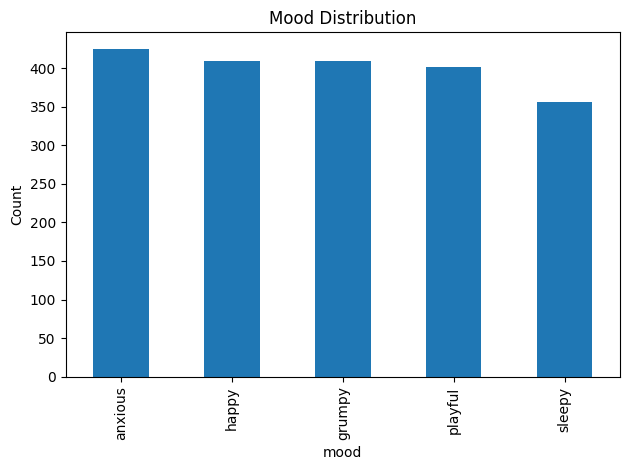

In [4]:
import matplotlib.pyplot as plt
df["mood"].value_counts().plot.bar(title="Mood Distribution")
plt.ylabel("Count")
plt.tight_layout()

## Baseline Check
Quick RF cross-val to confirm difficulty is in the 75-85% range.

In [5]:
import sys, os
sys.path.insert(0, os.getcwd())

from src.data.generate_synthetic import generate_dataset
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

df = generate_dataset(n_samples=2000, noise_rate=0.35)
enc = OrdinalEncoder()
df[["activity","tail_position","ear_direction"]] = enc.fit_transform(
    df[["activity","tail_position","ear_direction"]]
)
y = LabelEncoder().fit_transform(df["mood"])
X = df.drop(columns=["mood"]).values

scores = cross_val_score(RandomForestClassifier(n_estimators=100), X, y, cv=5)
print(f"Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

Accuracy: 0.839 ± 0.010


## Export

In [6]:
df.to_csv("../data/raw/cat_behavior_synthetic.csv", index=False)
print("Saved.")

Saved.
